# 03_Model_Analysis: モデル精度の詳細分析

このノートブックでは、モデルの過学習状況や限月別・会合までの日数別の精度を詳しく分析します。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# src読み込み用パス設定
sys.path.append('..')
from src.processing import load_and_clean_data
from src.features import generate_features
from src.pooling import pool_boj_data
from src.modeling import walk_forward_validation, calculate_metrics

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

## 1. データ準備と検証の実行

In [2]:
excel_path = '../data/BOJ_data.xlsx'
meeting_path = '../data/BOJ_meeting_history.csv'

df_clean = load_and_clean_data(excel_path, meeting_path)
df_feat = generate_features(df_clean)
df_pooled = pool_boj_data(df_feat)

horizons = [1, 3, 5]
results = {}
start_date = '2024-01-01'

for h in horizons:
    target_col = f'Target_{h}d'
    print(f"\n--- Running Validation for {target_col} ---")
    res = walk_forward_validation(df_pooled, target_col, start_date=start_date)
    results[h] = res


--- Running Validation for Target_1d ---
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[415]	train's rmse: 0.00368679	valid's rmse: 0.0160474
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[11]	train's rmse: 0.00951889	valid's rmse: 0.0103044
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[5]	train's rmse: 0.0101761	valid's rmse: 0.0128901
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[1]	train's rmse: 0.0112455	valid's rmse: 0.0172388
Training until validation scores don't improve for 100 rounds


...

Early stopping, best iteration is:
[28]	train's rmse: 0.0153039	valid's rmse: 0.0329993
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[60]	train's rmse: 0.0121643	valid's rmse: 0.0291949
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[493]	train's rmse: 0.00540228	valid's rmse: 0.060026
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[2]	train's rmse: 0.0339092	valid's rmse: 0.0319881
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[49]	train's rmse: 0.0164839	valid's rmse: 0.0380913


## 2. Days_to_MPM の事後マージ（疎結合化）

In [3]:
days_mpm = df_pooled[['Date', 'Meeting_Index', 'Days_to_MPM']].drop_duplicates()
for h in horizons:
    # src/modeling.py の返り値にも Days_to_MPM が含まれる場合があるため、重複を避けてマージ
    if 'Days_to_MPM' in results[h].columns:
        results[h] = results[h].drop(columns=['Days_to_MPM'])
    results[h] = results[h].merge(days_mpm, on=['Date', 'Meeting_Index'], how='left')

## 3. フォールド別ICの推移（安定性確認）

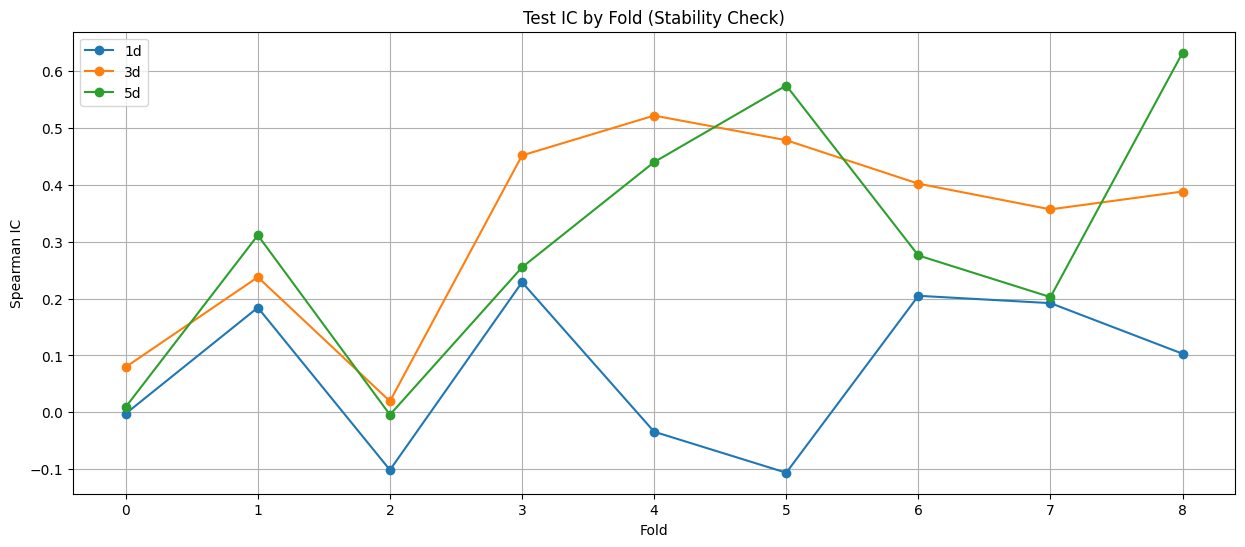

In [4]:
plt.figure(figsize=(15, 6))
for h in horizons:
    res = results[h]
    fold_ids = sorted(res['Fold'].unique())
    fold_ics = []
    for f in fold_ids:
        f_data = res[res['Fold'] == f]
        m = calculate_metrics(f_data['Actual'], f_data['Pred'])
        fold_ics.append(m['IC'])
    
    plt.plot(fold_ids, fold_ics, marker='o', label=f'{h}d')

plt.title("Test IC by Fold (Stability Check)")
plt.xlabel("Fold")
plt.ylabel("Spearman IC")
plt.legend()
plt.grid(True)
plt.show()

## 4. 訓練IC vs テストIC（過学習確認）

In [5]:
for h in horizons:
    res = results[h]
    # 最終フォールドの情報を代表として確認
    last_fold_idx = res['Fold'].max()
    last_fold = res[res['Fold'] == last_fold_idx]
    test_ic = calculate_metrics(last_fold['Actual'], last_fold['Pred'])['IC']
    train_ic = last_fold['Train_IC'].iloc[0]
    
    print(f"Horizon {h}d (Last Fold {last_fold_idx}): Train IC = {train_ic:.4f}, Test IC = {test_ic:.4f}")

Horizon 1d (Last Fold 8): Train IC = 0.5631, Test IC = 0.1031
Horizon 3d (Last Fold 8): Train IC = 0.8015, Test IC = 0.3885
Horizon 5d (Last Fold 8): Train IC = 0.7981, Test IC = 0.6329


## 5. Meeting_Index別（限月別）の精度

In [6]:
m_idx_stats = []
for h in horizons:
    res = results[h]
    for idx in range(1, 9):
        idx_data = res[res['Meeting_Index'] == idx]
        if len(idx_data) < 2: continue
        m = calculate_metrics(idx_data['Actual'], idx_data['Pred'])
        m['Horizon'] = f'{h}d'
        m['Meeting_Index'] = idx
        m_idx_stats.append(m)

df_m_idx = pd.DataFrame(m_idx_stats)
pivot_ic = df_m_idx.pivot(index='Meeting_Index', columns='Horizon', values='IC')
pivot_acc = df_m_idx.pivot(index='Meeting_Index', columns='Horizon', values='Direction_Accuracy_LargeMove')

print("--- IC by Meeting Index ---")
display(pivot_ic)
print("\n--- Large Move Direction Accuracy by Meeting Index ---")
display(pivot_acc)

--- IC by Meeting Index ---


Horizon,1d,3d,5d
Meeting_Index,,,
1,-0.004674,0.206290,0.148124
2,0.012934,0.252133,0.242981
3,0.054283,0.305395,0.255345
4,0.095977,0.334665,0.274754
5,0.087605,0.337084,0.263406
6,0.073487,0.321004,0.246067
7,0.063114,0.295049,0.208943
8,0.098046,0.292465,0.215335



--- Large Move Direction Accuracy by Meeting Index ---


Horizon,1d,3d,5d
Meeting_Index,,,
1,0.494382,0.686869,0.630000
2,0.514851,0.762376,0.724490
3,0.561224,0.762376,0.797980
4,0.580000,0.757576,0.802083
5,0.603960,0.793814,0.742574
6,0.556701,0.762376,0.712871
7,0.524752,0.762376,0.730000
8,0.564356,0.782178,0.742574


## 6. Days_to_MPM別（会合までの日数別）の精度

In [7]:
days_stats = []
for h in horizons:
    res = results[h]
    # 5日以内を「直前」、それ以外を「平常」とする
    res['Is_Pre_Meeting'] = (res['Days_to_MPM'] <= 5).astype(int)
    
    for pre in [0, 1]:
        d_data = res[res['Is_Pre_Meeting'] == pre]
        if len(d_data) < 2: continue
        m = calculate_metrics(d_data['Actual'], d_data['Pred'])
        m['Horizon'] = f'{h}d'
        m['Period'] = 'Pre-Meeting' if pre == 1 else 'Normal'
        days_stats.append(m)

df_days = pd.DataFrame(days_stats)
pivot_days = df_days.pivot(index='Horizon', columns='Period', values='Direction_Accuracy_LargeMove')
print("--- Large Move Direction Accuracy: Pre-Meeting vs Normal ---")
display(pivot_days)

--- Large Move Direction Accuracy: Pre-Meeting vs Normal ---


Period,Normal,Pre-Meeting
Horizon,,
1d,0.598854,0.348624
3d,0.684971,0.954545
5d,0.645441,0.888889
